<a href="https://colab.research.google.com/github/PC-Tam/GTSRB-DeepLearning-Classification/blob/main/notebooks/section1_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
from torchvision import datasets
from sklearn.model_selection import train_test_split

BASE_DIR = '/content/drive/MyDrive/Deep_Learning'
gtsrb_root = os.path.join(BASE_DIR, 'data/extracted')

# 1. Tự động quét tìm folder chứa 43 lớp biển báo
train_dir = None
for root, dirs, files in os.walk(gtsrb_root):
    subdirs = [d for d in dirs if d.isdigit() or (d.startswith('0') and d.replace('0', '').isdigit())]
    if len(subdirs) >= 40:
        train_dir = root
        break

if train_dir is None:
    raise FileNotFoundError("Không tìm thấy thư mục chứa các folder số của GTSRB.")

print("Thư mục huấn luyện gốc tìm thấy:", train_dir)

# 2. Quét toàn bộ đường dẫn ảnh
raw_data = datasets.ImageFolder(train_dir)
img_paths = [img[0] for img in raw_data.imgs]

# 3. Lấy trực tiếp ClassID từ tên thư mục cha để chống lệch nhãn tuyệt đối khi demo
targets = [int(Path(p).parent.name) for p in img_paths]

# 4. Thực hiện chia Stratified Split đều 43 lớp (80% Train, 20% Val)
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

# 5. Tạo folder splits lưu trữ file chỉ mục
SPLITS_DIR = os.path.join(BASE_DIR, 'data/splits')
os.makedirs(SPLITS_DIR, exist_ok=True)

# Ghi file CSV chỉ mục ra Drive chung của nhóm
pd.DataFrame({'path': [img_paths[i] for i in train_idx], 'label': [targets[i] for i in train_idx]}).to_csv(os.path.join(SPLITS_DIR, 'train.csv'), index=False)
pd.DataFrame({'path': [img_paths[i] for i in val_idx], 'label': [targets[i] for i in val_idx]}).to_csv(os.path.join(SPLITS_DIR, 'val.csv'), index=False)

# 6. Tạo file class_mapping.json chuẩn từ danh sách Class ID thực tế
unique_classes = sorted(list(set(targets)))
class_mapping = {int(cls): f"{cls:05d}" if isinstance(cls, int) else str(cls) for cls in unique_classes}

with open(os.path.join(SPLITS_DIR, 'class_mapping.json'), 'w') as f:
    json.dump(class_mapping, f, indent=4)

print(f"Đã cập nhật dữ liệu và lưu vào {SPLITS_DIR}!")
print(f"Tổng kết dữ liệu: Train = {len(train_idx)} ảnh | Val = {len(val_idx)} ảnh | Tổng số lớp = {len(unique_classes)}")

Thư mục huấn luyện gốc tìm thấy: /content/drive/MyDrive/Deep_Learning/data/extracted/Train
[OK] Đã cập nhật dữ liệu và lưu vào /content/drive/MyDrive/Deep_Learning/data/splits!
Tổng kết dữ liệu: Train = 31367 ảnh | Val = 7842 ảnh | Tổng số lớp = 43


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

BASE_DIR = '/content/drive/MyDrive/Deep_Learning'
SPLITS_DIR = os.path.join(BASE_DIR, 'data/splits')

class GTSRBSharedDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = int(self.df.iloc[idx]['label'])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

# Pipeline biến đổi cho tập Train
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Pipeline biến đổi cho tập Validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Khởi tạo Dataset dựa trên các file chỉ mục trong splits/
train_set = GTSRBSharedDataset(csv_file=os.path.join(SPLITS_DIR, 'train.csv'), transform=train_transform)
val_set = GTSRBSharedDataset(csv_file=os.path.join(SPLITS_DIR, 'val.csv'), transform=val_transform)

# Đóng gói DataLoader để nạp vào mô hình khi train
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

print("DataLoader cho tập Train và Val đã xong")

[OK] DataLoader cho tập Train và Val đã sẵn sàng!


Đang lấy dữ liệu mẫu từ train_loader để hiển thị...


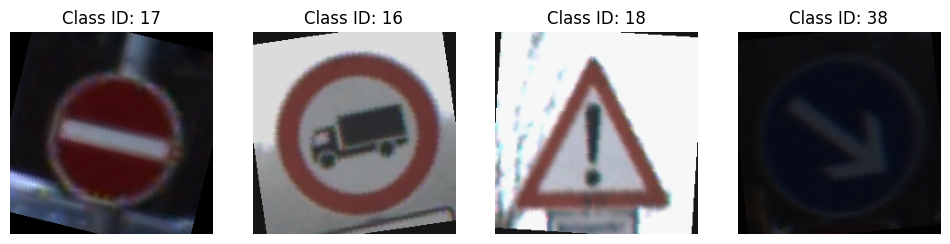

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Đang lấy dữ liệu mẫu từ train_loader để hiển thị...")
# Lấy thử 1 batch dữ liệu mẫu
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i, ax in enumerate(axes):
    img = images[i].numpy().transpose((1, 2, 0))
    # Khôi phục màu thực tế trước khi chuẩn hóa ImageNet để hiển thị ảnh rõ nét
    img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

    ax.imshow(img)
    ax.set_title(f"Class ID: {labels[i].item()}")
    ax.axis('off')

plt.show()